# Programming with ALPACA

ALPACA runs a special version of Python called MicroPython on its own. Therefore, you have to send your code for ALPACA to execute it.

Therefore, a package called **Belay** allows you to easily send and run bits of your python code on the ALPACA.



## Running your first code

After connecting the ALPACA to your computer via USB you can access the device:

```python
from belay import Device, list_devices

# 'list_devices()' gets all connected boards to your computer
# and the first element is most likely the ALPACA. 
pico = Device(list_devices()[0].to_port())
```

To identify which code part needs to be seen by the ALPACA and which code part needs to be seen by your computer, you can 'tag' functions that will be executed in ALPACA using `@pico.task`

```python
@pico.task
def hello():
    print("Hello from ALPACA!")

hello()
print("Hello from PC")
```

```{figure} ../images/alpaca/code_diagram.webp
---
max-height: 300px
name: ALPACA Digital Input Example
class: no-invert
---
```

:::{important}
The **ALPACA environment** and your **computer environment** are completely separate: variables and packages (like numpy) are **not shared** between them. To move data across, you must **send/receive it via arguments and return values**.
:::

:::{admonition} DON'T
:class: danger

Here, `i` is **not passed as an argument**, so ALPACA has no way to read or write it.

```python
i = 1

@pico.task
def increment():
    global i
    i += 1  # i not found

increment()
print(i)  # Even if it didn't error, it would print 1
```
:::

:::{admonition} DO
:class: tip

By passing `i` as an **argument**, Belay knows exactly what value to send to ALPACA, and what to retrieve back.

```python
i = 1

@pico.task
def increment(i):
    return i + 1

i = increment(i)
print(i)  # 2
```
:::

# Modules

Some modules aren't available in ALPACA and some modules aren't available in the computer. These are the **modules that are available on ALPACA only:**

## `machine` - functions related to the hardware

This module contains functions to control hardware on ALPACA like the digital pins or the analog to digital converter.


## `utime` - time related functions

When working with signals you need to deal with time-senstivity at microscale. `utime` provides functions for this exact purpose.

```python
@pico.task
def blink_led():
    '''Turns on the LED on DO10 and turns it off after 500ms'''
    from machine import Pin
    from utime import sleep_ms

    led = Pin(10, Pin.OUT) # Digital Output 10

    led.value(1)
    sleep_ms(500)
    led.value(0)
```


In boards, time is compared as <font color="#00819b">**ticks**</font>, they are just <font color="#00819b">a running clock, in milliseconds, since the board booted up.</font>


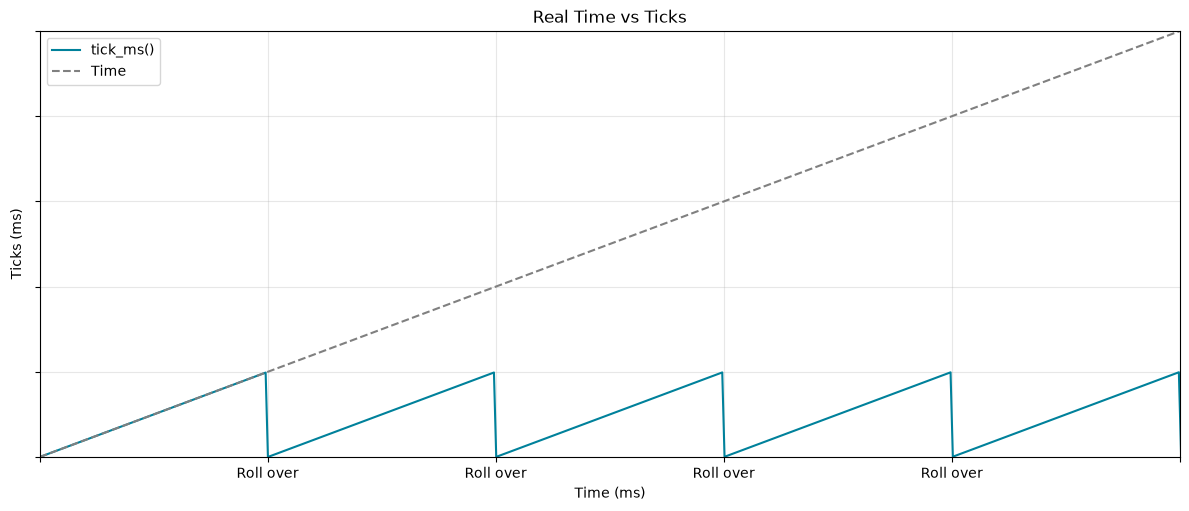

In [1]:
import matplotlib.pyplot as plt
import numpy as np

t = np.linspace(0, 200, 1000)

plt.figure(figsize=(12, 5))
plt.grid(alpha=0.3)
plt.plot(t, t % 20, color="#00819b", label="tick_ms()")
plt.plot(t, t, color="gray", linestyle="dashed", label="Time")

plt.legend()

plt.xticks(np.arange(0, 200, 20), labels=[""] + ["Roll over" for _ in range(4)] + [""] * 5)
plt.gca().set_yticklabels([])

plt.ylim(0, 100)
plt.xlim(0, 100)

plt.ylabel("Ticks (ms)")
plt.xlabel("Time (ms)")

plt.tight_layout()
plt.title("Real Time vs Ticks")
plt.show()


But the <font color="#00819b">tick</font> itself is never useful cause sometimes <font color="#00819b">**it rollsover to 0 (as it can't count forever)**</font> (see the figure above). Therefore, using `utime.ticks_add(a, b)` and `utime.ticks_diff(a, b)` (basically a + b and a - b) is <font color="#00819b">**essential**</font> when calculating time.

```python
@pico.task
def acquire_data():
    '''Samples for 500ms and returns the average'''
    import utime as time
    from machine import ADC

    adc0 = ADC(26)

    total = 0
    n = 0

    # 500ms in the future
    deadline = ticks_add(time.ticks_ms(), 500)

    # Run until deadline - now < 0, so until the deadline is passed
    while time.ticks_diff(deadline, time.ticks_ms()) < 0:
        n += 1
        total += adc0.read_u16()

    return total * 3.3 / 2**16 / n
```